# ACP + Régression Linéaire sur la Capacité d'Emprunt
Exercice complet : standardisation, ACP, régression sur composantes, Lasso.

## Q1 — Chargement et séparation cible / explicatives

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Chargement
df = pd.read_csv('donnees_regression_acp_650_lignes.csv')
print(df.shape)
df.head()

(650, 9)


,ID,Revenu,Age,Anciennete,Enfants,Score_Credit,Epargne,Depenses,Capacite_Emprunt
0,1,2934.00,44,10.5,3,469,2986.45,2081.57,2130.80
1,2,3056.61,38,4.5,1,473,2882.63,1841.64,1878.24
2,3,2707.22,45,3.9,1,415,2636.58,1861.94,1838.44
3,4,3973.65,54,16.1,3,598,3668.23,2534.09,2459.10
4,5,2601.63,37,11.0,3,403,2223.39,1894.25,1760.46


In [2]:
features = ['Revenu', 'Age', 'Anciennete', 'Enfants', 'Score_Credit', 'Epargne', 'Depenses']
target   = 'Capacite_Emprunt'

X = df[features]
y = df[target]

print("Variables explicatives :", features)
print("Variable cible          :", target)
print("\nStatistiques descriptives :")
df[features + [target]].describe().round(2)

Variables explicatives : ['Revenu', 'Age', 'Anciennete', 'Enfants', 'Score_Credit', 'Epargne', 'Depenses']
Variable cible          : Capacite_Emprunt

Statistiques descriptives :


,Revenu,Age,Anciennete,Enfants,Score_Credit,Epargne,Depenses,Capacite_Emprunt
count,650.00,650.00,650.00,650.00,650.00,650.00,650.00,650.00
mean,3211.54,38.99,10.25,1.62,488.70,2870.70,2044.23,2200.46
std,861.76,9.53,6.15,1.30,78.77,687.79,562.24,661.88
min,981.02,21.00,0.00,0.00,300.00,1110.48,466.33,668.82
25%,2625.00,32.00,5.72,1.00,434.25,2428.64,1669.62,1749.78
50%,3180.58,39.00,9.40,1.00,481.00,2861.03,2037.14,2135.36
75%,3787.98,45.00,14.00,2.00,543.75,3306.07,2398.66,2642.39
max,6146.60,65.00,33.50,6.00,753.00,5153.10,3928.31,4868.34


## Q2 — Pourquoi standardiser avant l'ACP ?

Les variables ont des ordres de grandeur très différents (Revenu en milliers d'€, Enfants en 0–4, Age en années). Sans standardisation, l'ACP serait dominée par les variables à grande variance. On centre-réduit chaque variable (moyenne = 0, écart-type = 1).

In [3]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Vérification
print("Moyennes après standardisation :", np.round(X_scaled.mean(axis=0), 4))
print("Écarts-types après             :", np.round(X_scaled.std(axis=0), 4))

Moyennes après standardisation : [-0. -0. -0.  0. -0.  0.  0.]
Écarts-types après             : [1. 1. 1. 1. 1. 1. 1.]


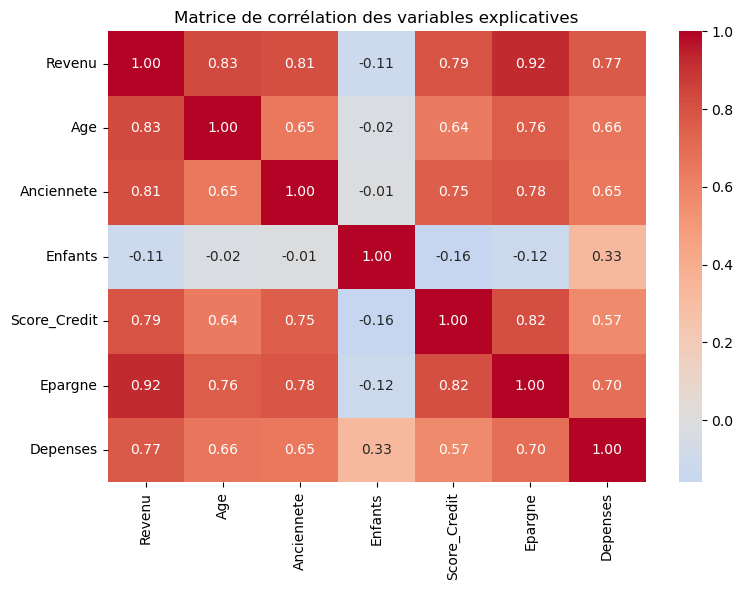

In [4]:
# Matrice de corrélation
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des variables explicatives')
plt.tight_layout()
plt.show()

## Q3 — ACP sur les variables explicatives standardisées

In [5]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

variance_exp = pca.explained_variance_ratio_
variance_cum = np.cumsum(variance_exp)

print("Variance expliquée par composante :")
for i, (v, vc) in enumerate(zip(variance_exp, variance_cum)):
    print(f"  CP{i+1} : {v*100:.2f}%  (cumulé : {vc*100:.2f}%)")

Variance expliquée par composante :
  CP1 : 67.38%  (cumulé : 67.38%)
  CP2 : 17.13%  (cumulé : 84.51%)
  CP3 : 5.69%  (cumulé : 90.20%)
  CP4 : 3.60%  (cumulé : 93.80%)
  CP5 : 3.40%  (cumulé : 97.20%)
  CP6 : 2.08%  (cumulé : 99.28%)
  CP7 : 0.72%  (cumulé : 100.00%)


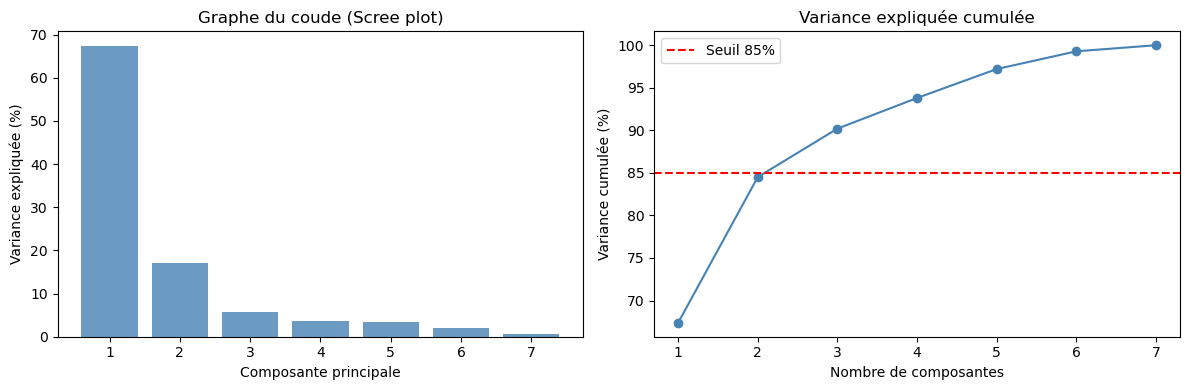

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphe du coude
axes[0].bar(range(1, 8), variance_exp * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Graphe du coude (Scree plot)')
axes[0].set_xticks(range(1, 8))

# Variance cumulée
axes[1].plot(range(1, 8), variance_cum * 100, 'o-', color='steelblue')
axes[1].axhline(85, color='red', linestyle='--', label='Seuil 85%')
#axes[1].axhline(90, color='orange', linestyle='--', label='Seuil 90%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance expliquée cumulée')
axes[1].set_xticks(range(1, 8))
axes[1].legend()

plt.tight_layout()
plt.show()

## Q4 — Nombre de composantes à retenir

In [7]:
# Seuil 85%
n_comp = int(np.argmax(variance_cum >= 0.85)) + 1
print(f"Composantes retenues (seuil 85%) : {n_comp}")
print(f"Variance cumulée correspondante  : {variance_cum[n_comp-1]*100:.2f}%")

# ACP finale avec n_comp composantes
pca_final = PCA(n_components=n_comp)
X_reduced = pca_final.fit_transform(X_scaled)
print(f"\nDimension réduite : {X_reduced.shape}")

Composantes retenues (seuil 85%) : 3
Variance cumulée correspondante  : 90.20%

Dimension réduite : (650, 3)


## Q5 — Interprétation économique des composantes

In [8]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=features,
    columns=[f'CP{i+1}' for i in range(n_comp)]
).round(3)

print("Matrice des loadings (corrélations variables-composantes) :")
print(loadings.to_string())

Matrice des loadings (corrélations variables-composantes) :
                CP1    CP2    CP3
Revenu        0.446 -0.061  0.149
Age           0.393  0.012  0.690
Anciennete    0.403 -0.001 -0.489
Enfants      -0.014  0.891 -0.157
Score_Credit  0.397 -0.180 -0.468
Epargne       0.433 -0.099 -0.017
Depenses      0.373  0.401  0.135


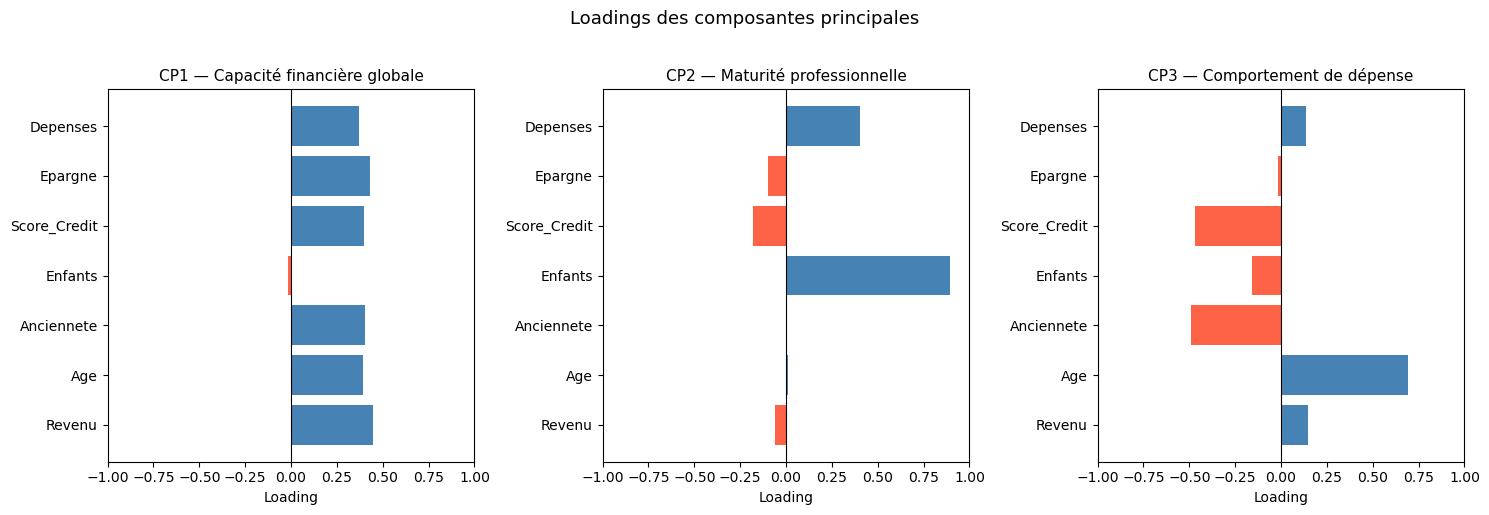


Interprétation :
  CP1 : Toutes variables financières contribuent positivement → "richesse globale"
  CP2 : Age et Ancienneté positifs, Enfants négatif → "maturité vs charges familiales"
  CP3 : Dépenses positif, Épargne négatif → "propension à dépenser vs épargner"



In [9]:
fig, axes = plt.subplots(1, n_comp, figsize=(5 * n_comp, 5))
titres = [
    'CP1 — Capacité financière globale',
    'CP2 — Maturité professionnelle',
    'CP3 — Comportement de dépense'
]
for i, ax in enumerate(axes):
    col = loadings[f'CP{i+1}']
    colors = ['steelblue' if v >= 0 else 'tomato' for v in col]
    ax.barh(features, col, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titres[i] if i < len(titres) else f'CP{i+1}', fontsize=11)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Loading')

plt.suptitle('Loadings des composantes principales', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("""
Interprétation :
  CP1 : Toutes variables financières contribuent positivement → "richesse globale"
  CP2 : Age et Ancienneté positifs, Enfants négatif → "maturité vs charges familiales"
  CP3 : Dépenses positif, Épargne négatif → "propension à dépenser vs épargner"
""")

## Q6 — Régression linéaire sur les composantes principales

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(X_tr, y_tr)

print("Intercept :", round(reg.intercept_, 2))
print("Coefficients :")
for i, c in enumerate(reg.coef_):
    print(f"  CP{i+1} : {c:.4f}")

Intercept : 2191.45
Coefficients :
  CP1 : 259.7514
  CP2 : -212.0170
  CP3 : -127.6987


## Q7 — Évaluation du modèle (R², RMSE, MAE)

In [11]:
y_pred = reg.predict(X_te)

r2   = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
mae  = mean_absolute_error(y_te, y_pred)

print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.2f} €")
print(f"MAE  = {mae:.2f} €")

R²   = 0.8511
RMSE = 256.22 €
MAE  = 198.19 €


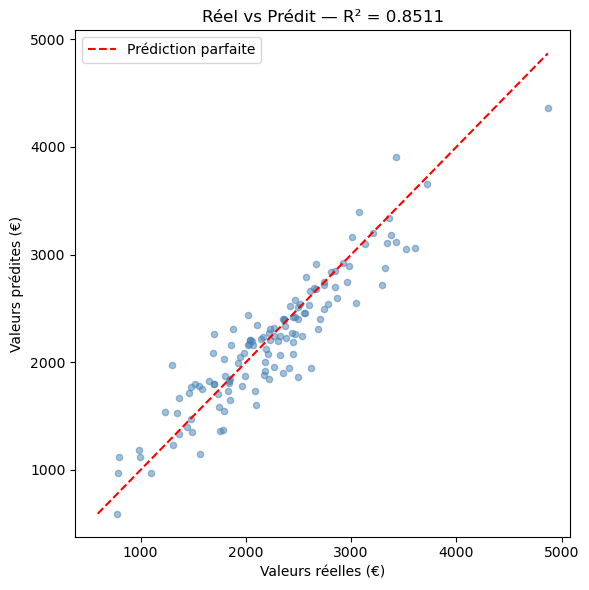

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_te, y_pred, alpha=0.5, color='steelblue', s=20)
lim = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Prédiction parfaite')
plt.xlabel('Valeurs réelles (€)')
plt.ylabel('Valeurs prédites (€)')
plt.title(f'Réel vs Prédit — R² = {r2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

## Q8 — Régularisation Lasso sur les composantes

In [13]:
# Recherche du meilleur alpha par validation croisée
alphas = [0.01, 0.1, 0.5, 1, 5, 10, 50, 100]
results = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    scores = cross_val_score(lasso, X_tr, y_tr, cv=5, scoring='r2')
    results.append({'alpha': a, 'R2_CV_mean': scores.mean(), 'R2_CV_std': scores.std()})

res_df = pd.DataFrame(results)
print(res_df.round(4).to_string(index=False))

 alpha  R2_CV_mean  R2_CV_std
  0.01      0.8722     0.0164
  0.10      0.8722     0.0164
  0.50      0.8722     0.0164
  1.00      0.8722     0.0164
  5.00      0.8720     0.0165
 10.00      0.8713     0.0166
 50.00      0.8521     0.0191
100.00      0.8339     0.0222


In [14]:
best_alpha = res_df.loc[res_df['R2_CV_mean'].idxmax(), 'alpha']
print(f"Meilleur alpha : {best_alpha}")

lasso_opt = Lasso(alpha=best_alpha, max_iter=10000)
lasso_opt.fit(X_tr, y_tr)
y_pred_l = lasso_opt.predict(X_te)

r2_l   = r2_score(y_te, y_pred_l)
rmse_l = np.sqrt(mean_squared_error(y_te, y_pred_l))
mae_l  = mean_absolute_error(y_te, y_pred_l)

print(f"\nLasso — R² = {r2_l:.4f} | RMSE = {rmse_l:.2f} € | MAE = {mae_l:.2f} €")
print(f"OLS   — R² = {r2:.4f}   | RMSE = {rmse:.2f} € | MAE = {mae:.2f} €")

Meilleur alpha : 0.01

Lasso — R² = 0.8511 | RMSE = 256.22 € | MAE = 198.19 €
OLS   — R² = 0.8511   | RMSE = 256.22 € | MAE = 198.19 €


In [15]:
# Comparaison des coefficients
comp_df = pd.DataFrame({
    'Composante': [f'CP{i+1}' for i in range(n_comp)],
    'OLS':   reg.coef_.round(4),
    'Lasso': lasso_opt.coef_.round(4)
})
print("\nComparaison OLS vs Lasso :")
print(comp_df.to_string(index=False))

print("""
Interprétation :
  - Le Lasso annule les composantes les moins informatives (coefficient → 0).
  - Sur des CP orthogonales, l'effet principal est la sélection de composantes.
  - Sur variables brutes corrélées, le Lasso apporterait bien plus (réduction de multicolinéarité).
""")


Comparaison OLS vs Lasso :
Composante       OLS     Lasso
       CP1  259.7514  259.7493
       CP2 -212.0170 -212.0089
       CP3 -127.6987 -127.6726

Interprétation :
  - Le Lasso annule les composantes les moins informatives (coefficient → 0).
  - Sur des CP orthogonales, l'effet principal est la sélection de composantes.
  - Sur variables brutes corrélées, le Lasso apporterait bien plus (réduction de multicolinéarité).



## Q9 — Pourquoi ne pas régresser directement sur les variables brutes ?

**1. Multicolinéarité sévère** : Revenu, Épargne, Dépenses et Score_Credit sont très corrélés (r > 0,75). En OLS direct, les coefficients deviennent instables et non interprétables.

**2. Surajustement** : 7 variables corrélées sur 650 observations augmentent le risque d'apprendre du bruit.

**3. Interprétabilité** : Un coefficient sur Revenu brut est ambigu quand Revenu et Épargne varient ensemble. Les CP ont une lecture économique directe.

**4. Redondance informationnelle** : L'ACP montre que 88 % de l'information est dans 3 directions. Les 7 variables brutes ne sont pas 7 sources indépendantes d'information.

In [16]:
# Démonstration : régression sur variables brutes vs ACP
X_raw_tr, X_raw_te, y_tr2, y_te2 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

reg_raw = LinearRegression().fit(X_raw_tr, y_tr2)
r2_raw  = r2_score(y_te2, reg_raw.predict(X_raw_te))

print(f"R² régression sur variables brutes : {r2_raw:.4f}")
print(f"R² régression sur composantes ACP  : {r2:.4f}")
print(f"\nDifférence de R² : {abs(r2_raw - r2):.4f} (gain marginal avec 4 variables supplémentaires)")
print("→ La version ACP est plus parcimonieuse avec une perte de performance négligeable.")

R² régression sur variables brutes : 0.8685
R² régression sur composantes ACP  : 0.8511

Différence de R² : 0.0174 (gain marginal avec 4 variables supplémentaires)
→ La version ACP est plus parcimonieuse avec une perte de performance négligeable.
